In [27]:
# tmp_qaoa_ket_4wagons.py
#
# Toy TMP -> QAOA in Ket-LANG
#
# Inbound train:  (1, 2, 3, 4)
# Target outbound: (4, 3, 2, 1)
#
# Yard abstraction:
# - 2 classification tracks: A and B
# - 2 slots per track
# - LIFO pull-out
# - outbound train formed by Track B first, then Track A
#
# Binary variable:
#   x_{i,t,p} in {0,1}
#   wagon i assigned to track t, slot p
#
# Direct encoding:
#   4 wagons x 2 tracks x 2 slots = 16 qubits
#
# Note:
#   This stays within a 20-qubit budget, but it does not use exactly 20 qubits.
#   To force exactly 20 qubits, you would need to allocate 4 extra idle qubits,
#   which is usually not useful.

from functools import partial

from ket import *
from scipy.optimize import minimize

In [28]:
# ------------------------------------------------------------
# 1) Toy TMP instance
# ------------------------------------------------------------

NUM_WAGONS = 4
TRACKS = ["A", "B"]
SLOTS_PER_TRACK = 2

# Penalty coefficients
LAMBDA_WAGON = 20.0
LAMBDA_SLOT = 20.0

# QAOA depth
P_LAYERS = 2

In [29]:
# ------------------------------------------------------------
# 2) Indexing helpers
# ------------------------------------------------------------

def variable_index(i: int, t: str, p: int) -> int:
    """
    Flatten x_{i,t,p} into a qubit index.

    i in {1,2,3,4}
    t in {'A','B'}
    p in {1,2}
    """
    t_idx = 0 if t == "A" else 1
    return (i - 1) * (len(TRACKS) * SLOTS_PER_TRACK) + t_idx * SLOTS_PER_TRACK + (p - 1)


def desired_wagon(t: str, p: int) -> int:
    """
    Desired wagon for slot p on track t.

    Under the toy abstraction:
    - Track B is pulled first, in reverse slot order -> yields (4,3)
    - Track A is pulled second, in reverse slot order -> yields (2,1)

    Using the simplified slot convention:
    - Track A ideal loading: slot 1 -> wagon 1, slot 2 -> wagon 2
    - Track B ideal loading: slot 1 -> wagon 3, slot 2 -> wagon 4
    """
    if t == "A":
        return p          # 1, 2
    return p + 2          # 3, 4


def placement_cost(i: int, t: str, p: int) -> float:
    """
    c_{i,t,p} = (i - d_{t,p})^2
    """
    d_tp = desired_wagon(t, p)
    return float((i - d_tp) ** 2)

In [30]:
# ------------------------------------------------------------
# 3) Hamiltonians
# ------------------------------------------------------------
def x_op(q):
    return (1 - Z(q)) / 2

In [31]:
# def objective_h(qubits: Quant):
#     """
#     H_obj = sum_{i,t,p} c_{i,t,p} B(q_{i,t,p})
# 
#     Ket provides B(q) = (1 - Z(q)) / 2 for QUBO binary variables.
#     """
#     with obs():
#         h_obj = 0
#         for i in range(1, NUM_WAGONS + 1):
#             for t in TRACKS:
#                 for p in range(1, SLOTS_PER_TRACK + 1):
#                     q_idx = variable_index(i, t, p)
# 
#                     # REPLACING THIS ERROR
#                     #h_obj += placement_cost(i, t, p) * B(qubits[q_idx])
# 
#                     # A NEW APPROACH
#                     h_obj += placement_cost(i, t, p) * ((1 - Z(qubits[q_idx])) / 2)
#     return h_obj

In [32]:
# New function
def objective_h(qubits: Quant): 
    with obs():
        h_obj = 0
        for i in range(1, NUM_WAGONS + 1):
            for t in TRACKS:
                for p in range(1, SLOTS_PER_TRACK + 1):
                    q_idx = variable_index(i, t, p)
                    h_obj += placement_cost(i, t, p) * x_op(qubits[q_idx])
    return h_obj

In [33]:
#######################################################
# issue with power ** not supported by hamiltonian Ket
#
def wagon_constraint_h_OLD(qubits: Quant):
    """
    P_wagon = lambda * sum_i (1 - sum_{t,p} x_{i,t,p})^2
    """
    with obs():
        penalty = 0
        for i in range(1, NUM_WAGONS + 1):
            s_i = 0
            for t in TRACKS:
                for p in range(1, SLOTS_PER_TRACK + 1):
                    q_idx = variable_index(i, t, p)

                    # replacing
                    # s_i += B(qubits[q_idx])
                    s_i += x_op(qubits[q_idx])
                    
            penalty += (1 - s_i) ** 2
    return LAMBDA_WAGON * penalty

#######################################################
# THE NEW FUNCTION
#
def wagon_constraint_h(qubits: Quant):
    """
    P_wagon = lambda * sum_i (1 - sum_{t,p} x_{i,t,p})^2

    Expanded using binary-variable identities:
        (1 - sum x_k)^2 = 1 - sum x_k + 2 * sum_{a<b} x_a x_b
    """
    with obs():
        penalty = 0

        for i in range(1, NUM_WAGONS + 1):
            vars_i = []
            for t in TRACKS:
                for p in range(1, SLOTS_PER_TRACK + 1):
                    q_idx = variable_index(i, t, p)
                    vars_i.append(x_op(qubits[q_idx]))

            # constant term
            term = 1

            # linear terms: -sum x_k
            for xk in vars_i:
                term += -xk

            # quadratic terms: +2 sum_{a<b} x_a x_b
            for a in range(len(vars_i)):
                for b in range(a + 1, len(vars_i)):
                    term += 2 * vars_i[a] * vars_i[b]

            penalty += term

    return LAMBDA_WAGON * penalty

#######################################################
# issue with power ** not supported by hamiltonian Ket
def slot_constraint_h_OLD(qubits: Quant):
    """
    P_slot = lambda * sum_{t,p} (1 - sum_i x_{i,t,p})^2
    """
    with obs():
        penalty = 0
        for t in TRACKS:
            for p in range(1, SLOTS_PER_TRACK + 1):
                s_tp = 0
                for i in range(1, NUM_WAGONS + 1):
                    q_idx = variable_index(i, t, p)
                    s_tp += B(qubits[q_idx])

                # issue with power ** not supported by hamiltonian Ket
                penalty += (1 - s_tp) ** 2
                
    return LAMBDA_SLOT * penalty
#

#######################################################
# THE NEW FUNCTION
def slot_constraint_h(qubits: Quant):
    """
    P_slot = lambda * sum_{t,p} (1 - sum_i x_{i,t,p})^2
    Expanded using binary-variable identities.
    """
    with obs():
        penalty = 0

        for t in TRACKS:
            for p in range(1, SLOTS_PER_TRACK + 1):
                vars_tp = []
                for i in range(1, NUM_WAGONS + 1):
                    q_idx = variable_index(i, t, p)
                    vars_tp.append(x_op(qubits[q_idx]))

                term = 1

                for xk in vars_tp:
                    term += -xk

                for a in range(len(vars_tp)):
                    for b in range(a + 1, len(vars_tp)):
                        term += 2 * vars_tp[a] * vars_tp[b]

                penalty += term

    return LAMBDA_SLOT * penalty
#
#######################################################


def cost_h(qubits: Quant):
    """
    Full QUBO/Ising cost Hamiltonian for the toy TMP.
    """
    return (
        objective_h(qubits)
        + wagon_constraint_h(qubits)
        + slot_constraint_h(qubits)
    )


def mixer_h(qubits: Quant):
    """
    Standard QAOA mixer:
        H_M = sum_j X_j
    """
    with obs():
        hm = sum(X(q) for q in qubits)
    return hm

In [34]:
# ------------------------------------------------------------
# 4) QAOA ansatz
# ------------------------------------------------------------

def qaoa_layer(qubits: Quant, gamma, beta):
    evolve(gamma * cost_h(qubits))
    evolve(beta * mixer_h(qubits))


def qaoa_ansatz(qubits: Quant, gamma_params, beta_params):
    for g, b in zip(gamma_params, beta_params):
        qaoa_layer(qubits, g, b)


In [35]:
# ------------------------------------------------------------
# 5) Objective for SciPy
# ------------------------------------------------------------

def qaoa_objective(num_qubits: int, parameters):
    """
    parameters = [beta_1, ..., beta_p, gamma_1, ..., gamma_p]
    """
    process = Process(
        num_qubits=num_qubits,
        simulator="dense",
        execution="batch",
    )

    p = len(parameters) // 2
    beta = parameters[:p]
    gamma = parameters[p:]

    qubits = process.alloc(num_qubits)

    # Initial uniform superposition
    H(qubits)

    # QAOA circuit
    qaoa_ansatz(qubits, gamma, beta)

    # Minimize expected TMP cost
    return exp_value(cost_h(qubits)).get()

In [36]:
# ------------------------------------------------------------
# 6) Classical decoding helpers
# ------------------------------------------------------------

def decode_bitstring(bitstring: str):
    """
    Decode a measured computational basis bitstring into active assignments.
    """
    active = []
    for i in range(1, NUM_WAGONS + 1):
        for t in TRACKS:
            for p in range(1, SLOTS_PER_TRACK + 1):
                idx = variable_index(i, t, p)
                if bitstring[idx] == "1":
                    active.append((i, t, p))
    return active


def reconstruct_tracks(assignments):
    """
    Return the slot occupancy of each track.
    """
    track_map = {("A", 1): None, ("A", 2): None, ("B", 1): None, ("B", 2): None}
    for i, t, p in assignments:
        track_map[(t, p)] = i

    track_a = [track_map[("A", 1)], track_map[("A", 2)]]
    track_b = [track_map[("B", 1)], track_map[("B", 2)]]
    return track_a, track_b


def outbound_sequence(track_a, track_b):
    """
    Outbound assembly:
    - Track B first, LIFO
    - then Track A, LIFO
    """
    return list(reversed(track_b)) + list(reversed(track_a))

In [37]:
# ------------------------------------------------------------
# 7) Optional final-state / sampling stub
# ------------------------------------------------------------

def run_final_circuit(best_parameters):
    """
    Prepares the optimized state.
    Add measurement / sampling according to your preferred workflow.
    """
    num_qubits = NUM_WAGONS * len(TRACKS) * SLOTS_PER_TRACK  # 16

    process = Process(
        num_qubits=num_qubits,
        simulator="dense",
        execution="batch",
    )

    p = len(best_parameters) // 2
    beta = best_parameters[:p]
    gamma = best_parameters[p:]

    qubits = process.alloc(num_qubits)
    H(qubits)
    qaoa_ansatz(qubits, gamma, beta)

    # Placeholder:
    # counts = sample(qubits, shots=1000).get()
    # best_bitstring = ...
    # assignments = decode_bitstring(best_bitstring)

    return process

In [38]:
# ------------------------------------------------------------
# 8) Main
# ------------------------------------------------------------

if __name__ == "__main__":
    num_qubits = NUM_WAGONS * len(TRACKS) * SLOTS_PER_TRACK  # 16

    # Initial guess: [beta_1, ..., beta_p, gamma_1, ..., gamma_p]
    initial_parameters = [0.1] * P_LAYERS + [0.1] * P_LAYERS

    result = minimize(
        partial(qaoa_objective, num_qubits),
        initial_parameters,
        method="COBYLA",
    )


In [39]:

    print("Optimization finished")
    print("Qubits used:", num_qubits)
    print("Best energy:", result.fun)
    print("Best parameters:", result.x)

    run_final_circuit(result.x)

Optimization finished
Qubits used: 16
Best energy: 117.80740755497763
Best parameters: [-0.52921795 -0.51847225 -0.30873228 -0.30111233]


<Ket 'Process' id=0x24fa3d817d0>

# GRAPH VISUALIZATION

## Optimized variational angles that define your final QAOA ansatz

## What this graph tells you

The next plot shows the optimized variational angles that define your final QAOA ansatz. In practical terms:
the γ values control how strongly the circuit evolves under the TMP cost Hamiltonian the β values control how strongly it evolves under the mixer Hamiltonian 

Since Ket implements QAOA by alternating evolve(gamma * cost_h(...)) and evolve(beta * mixer_h(...)), these four numbers are the actual learned controls of your 2-layer quantum circuit.

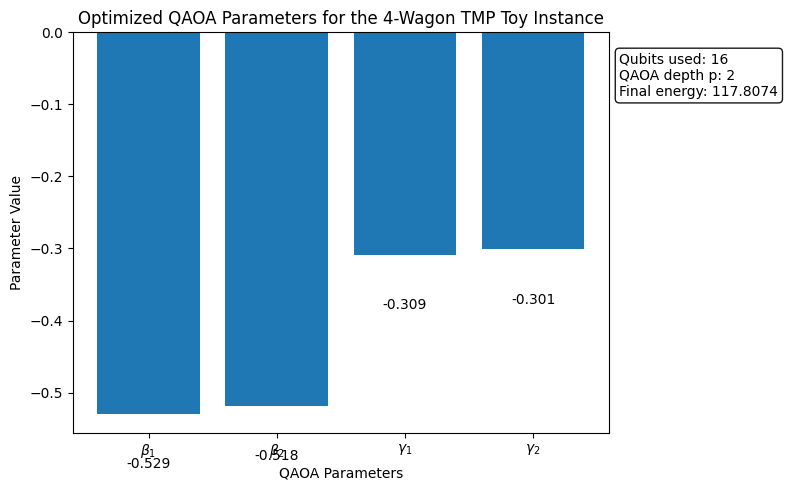

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Final optimization result from your run
best_energy = 117.80740755497763
best_parameters = np.array([-0.52921795, -0.51847225, -0.30873228, -0.30111233])

# Since P_LAYERS = 2:
p_layers = 2
beta = best_parameters[:p_layers]
gamma = best_parameters[p_layers:]

# Labels
beta_labels = [rf"$\beta_{{{i+1}}}$" for i in range(p_layers)]
gamma_labels = [rf"$\gamma_{{{i+1}}}$" for i in range(p_layers)]

# Combine for plotting
labels = beta_labels + gamma_labels
values = np.concatenate([beta, gamma])

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(labels))

bars = ax.bar(x, values)

ax.set_title("Optimized QAOA Parameters for the 4-Wagon TMP Toy Instance")
ax.set_xlabel("QAOA Parameters")
ax.set_ylabel("Parameter Value")
ax.set_xticks(x)
ax.set_xticklabels(labels)

# Annotate each bar
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + (0.02 if value >= 0 else -0.06),
        f"{value:.3f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=10,
    )

# Add a text box with summary info
summary_text = (
    f"Qubits used: 16\n"
    f"QAOA depth p: {p_layers}\n"
    f"Final energy: {best_energy:.4f}"
)

ax.text(
    1.02, 0.95, summary_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.tight_layout()
plt.show()

## Better graph: optimization convergence

Optimization finished
Qubits used: 16
Best energy: 117.80740755497763
Best parameters: [-0.52921795 -0.51847225 -0.30873228 -0.30111233]


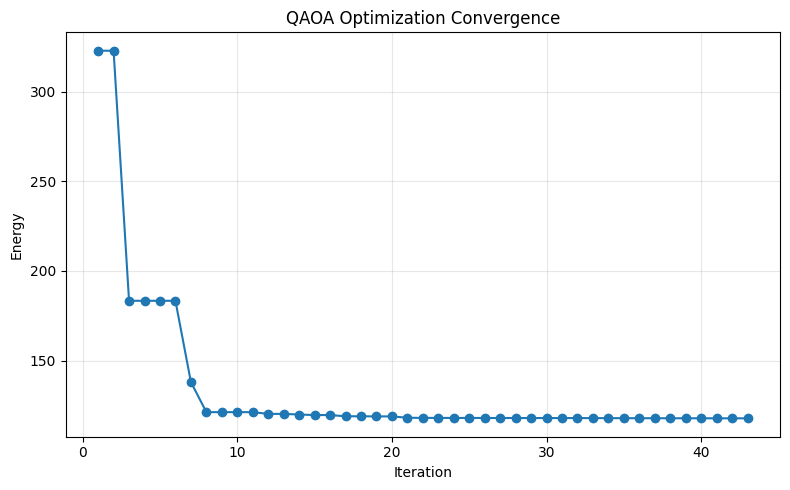

In [42]:
from functools import partial
from scipy.optimize import minimize
import matplotlib.pyplot as plt

history = []

def callback_fn(xk):
    # Re-evaluate the objective at the current point
    value = qaoa_objective(num_qubits, xk)
    history.append(value)

num_qubits = NUM_WAGONS * len(TRACKS) * SLOTS_PER_TRACK  # 16
initial_parameters = [0.1] * P_LAYERS + [0.1] * P_LAYERS

result = minimize(
    partial(qaoa_objective, num_qubits),
    initial_parameters,
    method="COBYLA",
    callback=callback_fn,
)

print("Optimization finished")
print("Qubits used:", num_qubits)
print("Best energy:", result.fun)
print("Best parameters:", result.x)

# Plot convergence
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(history) + 1), history, marker="o")
plt.title("QAOA Optimization Convergence")
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## the most meaningful application-level plot

this is the most meaningful application-level plot, because it shows whether the decoded marshaling solution actually matches the target outbound order.

The idea is:

define the target sequence as [4, 3, 2, 1]
take the best measured bitstring
decode it into wagon assignments
reconstruct Track A and Track B
derive the resulting outbound sequence
plot target vs decoded

Below is a clean plotting block for that.

In [43]:
import matplotlib.pyplot as plt
import numpy as np


def plot_target_vs_decoded(best_bitstring: str):
    """
    Compare the target outbound sequence with the decoded sequence
    obtained from the best measured bitstring.
    """
    # Target sequence for the 4-wagon toy TMP
    target_sequence = [4, 3, 2, 1]

    # Decode the bitstring into assignments
    assignments = decode_bitstring(best_bitstring)

    # Reconstruct track occupancy
    track_a, track_b = reconstruct_tracks(assignments)

    # Build outbound sequence under the toy abstraction
    decoded_sequence = outbound_sequence(track_a, track_b)

    print("Best bitstring:", best_bitstring)
    print("Decoded assignments:", assignments)
    print("Track A:", track_a)
    print("Track B:", track_b)
    print("Decoded outbound sequence:", decoded_sequence)
    print("Target outbound sequence :", target_sequence)

    # Plot
    x = np.arange(1, len(target_sequence) + 1)

    fig, ax = plt.subplots(figsize=(8, 5))
    width = 0.35

    ax.bar(x - width / 2, target_sequence, width, label="Target")
    ax.bar(x + width / 2, decoded_sequence, width, label="Decoded")

    ax.set_title("Target vs Decoded Outbound Sequence")
    ax.set_xlabel("Outbound Position")
    ax.set_ylabel("Wagon ID")
    ax.set_xticks(x)
    ax.legend()

    # Annotate bars
    for xpos, val in zip(x - width / 2, target_sequence):
        ax.text(xpos, val + 0.05, str(val), ha="center", va="bottom", fontsize=10)

    for xpos, val in zip(x + width / 2, decoded_sequence):
        ax.text(xpos, val + 0.05, str(val), ha="center", va="bottom", fontsize=10)

    # Match indicator
    is_match = decoded_sequence == target_sequence
    status_text = "Perfect match" if is_match else "Mismatch"

    ax.text(
        0.98, 0.95,
        status_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()

In [45]:
def decoded_qubo_quality(best_bitstring: str):
    assignments = decode_bitstring(best_bitstring)
    track_a, track_b = reconstruct_tracks(assignments)
    decoded_sequence = outbound_sequence(track_a, track_b)
    target_sequence = [4, 3, 2, 1]

    correct_positions = sum(
        1 for a, b in zip(decoded_sequence, target_sequence) if a == b
    )

    print("Decoded sequence:", decoded_sequence)
    print("Target sequence :", target_sequence)
    print(f"Correct positions: {correct_positions}/{len(target_sequence)}")

In [47]:
def plot_target_vs_decoded_lines(best_bitstring: str):
    target_sequence = [4, 3, 2, 1]
    assignments = decode_bitstring(best_bitstring)
    track_a, track_b = reconstruct_tracks(assignments)
    decoded_sequence = outbound_sequence(track_a, track_b)

    x = np.arange(1, len(target_sequence) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(x, target_sequence, marker="o", label="Target")
    plt.plot(x, decoded_sequence, marker="s", label="Decoded")

    plt.title("Target vs Decoded Outbound Sequence")
    plt.xlabel("Outbound Position")
    plt.ylabel("Wagon ID")
    plt.xticks(x)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Best bitstring: 1000010000100001
Decoded assignments: [(1, 'A', 1), (2, 'A', 2), (3, 'B', 1), (4, 'B', 2)]
Track A: [1, 2]
Track B: [3, 4]
Decoded outbound sequence: [4, 3, 2, 1]
Target outbound sequence : [4, 3, 2, 1]


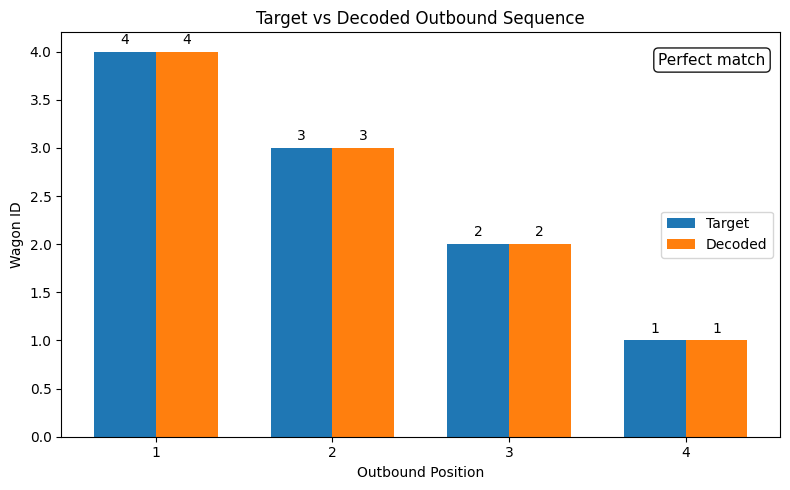

In [49]:
best_bitstring = "1000010000100001"   # replace with the best measured 16-bit solution
plot_target_vs_decoded(best_bitstring)